In [9]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy import sparse
from matplotlib import pyplot as plt
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)

In [2]:
FILE_NAME = "../data/pancreas.h5ad"
adata = sc.read(
    filename=FILE_NAME
)

/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [7]:
umap = adata.obsm["X_umap"]

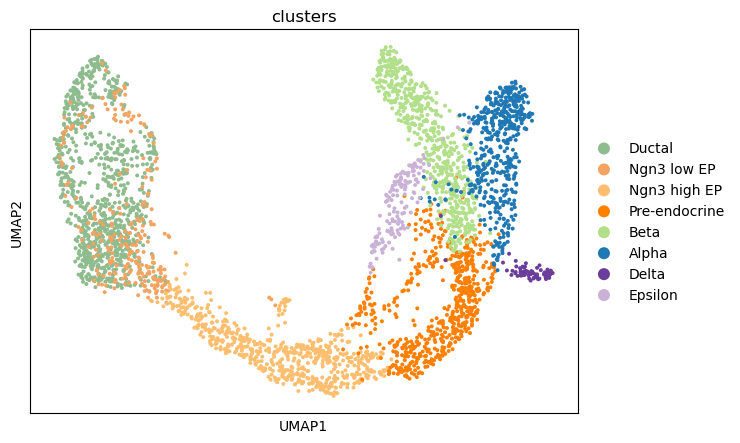

In [18]:
sc.pl.scatter(adata, basis="umap", color="clusters")

In [33]:
umap_half = umap[umap[:,0] < umap[:,0].mean()]
root_ixs = umap_half[:, 1].argmax()
# sc.pl.scatter(adata_half, basis="umap", color="clusters")
# root_ixs = adata_half.obsm["X_umap"][:, 1].argmax()
print(root_ixs)

484


In [34]:
umap[484]

array([2.8308012 , 0.19451131], dtype=float32)

In [36]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10)
sc.tl.leiden(adata)
leiden = adata.obs["leiden"].to_numpy(dtype=int)

In [37]:
projected_points, mst, centroids = learn_graph(matrix=umap, clusters=leiden)

In [42]:
pseudotime = order_cells(
    umap, centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=[root_ixs],
)


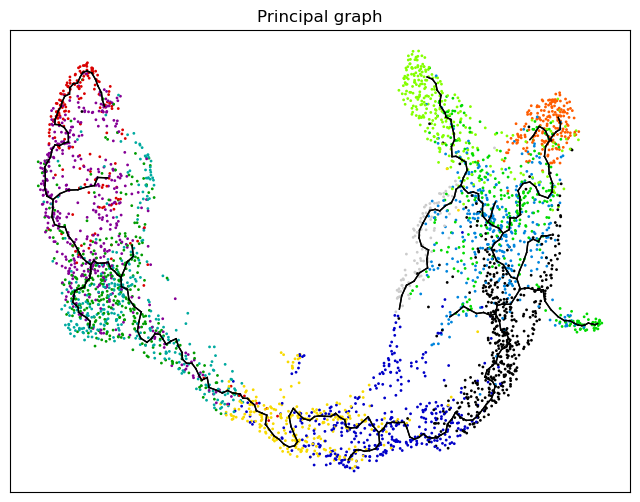

In [44]:
plt.figure(1, (8, 6))
plt.title("Principal graph")
plt.scatter(umap[:, 0], umap[:, 1], c=leiden, s=1, cmap="nipy_spectral")

edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

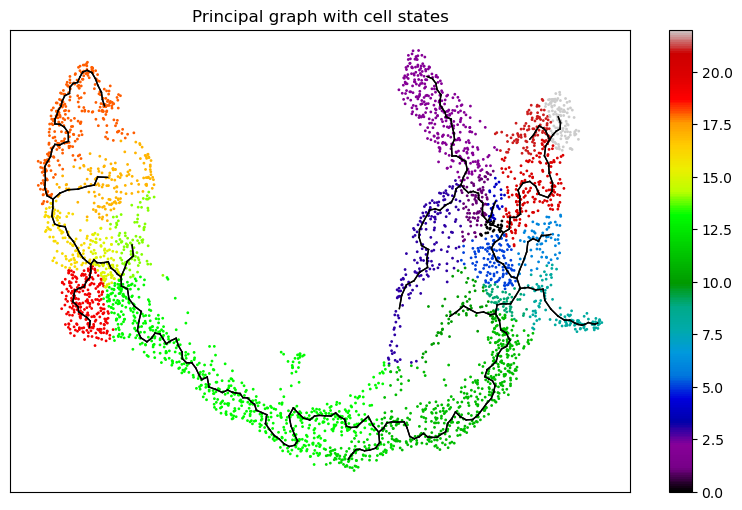

In [45]:
plt.figure(1, (10, 6))
plt.title("Principal graph with cell states")
cell_states, _ = compute_cell_states(umap, centroids, mst)
plt.scatter(umap[:, 0], umap[:, 1], c=cell_states, s=1, cmap="nipy_spectral")
plt.colorbar()
edges = np.array(mst.nonzero()).T
for edge in edges:
    plt.plot(centroids[edge, 0], centroids[edge, 1], c="black", linewidth=1)
plt.xticks([])
plt.yticks([])
plt.show()

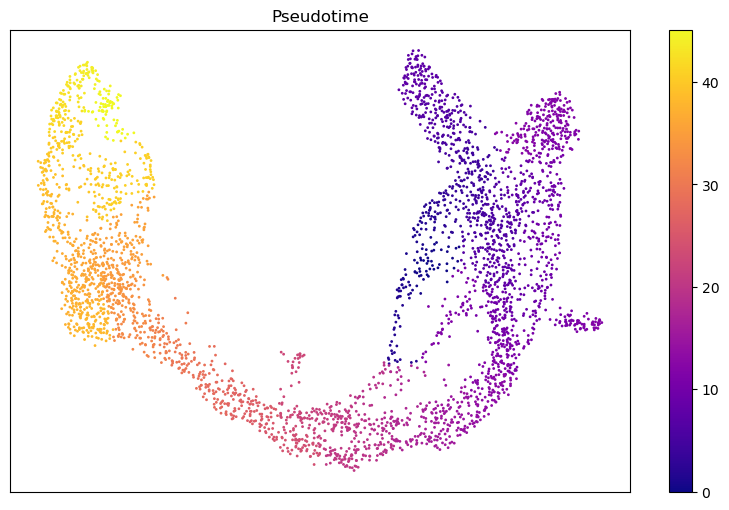

In [46]:
plt.figure(1, (10, 6))
plt.title("Pseudotime")
plt.scatter(umap[:, 0], umap[:, 1], c=pseudotime, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

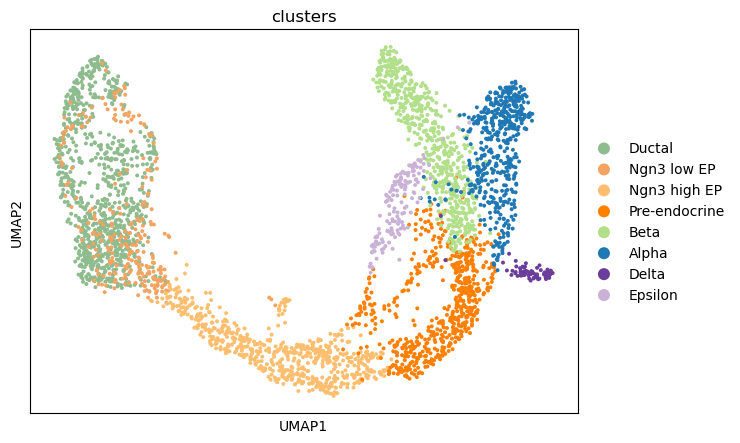